# Analysing the datasets information

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("plot_field_data_download.csv")
data.head()

,X,Y,plot_code,country_code,survey_date,altitude,longitude,latitude,tsu_id,plot_id,...,water_supply,irrigation_mode,irrigation_water_source,grazing_sign_present,grazing_sign_infrastructure,grazing_sign_droppings,grazing_sign_grass,overgrazing_sign_bare,overgrazing_sign_dung,overgrazing_sign_deforest
0,6.094781,7.423652,NG018-7-1,NG,2022/10/10,387,6.094781,7.423652,770960701201201,1,...,Rainfed,NaN,NaN,No,No,No,No,No,NaN,NaN
1,6.096257,7.424630,NG018-1-2,NG,2022/10/10,371,6.096257,7.424630,770960701101402,2,...,Rainfed,NaN,NaN,No,No,No,No,No,No,No
2,6.099892,7.418512,NG018-6-2,NG,2022/10/10,370,6.099892,7.418512,770960701801702,3,...,Rainfed,NaN,NaN,Yes,No,No,Yes,Yes,No,No
3,6.096048,7.417137,NG018-5-2,NG,2022/10/10,362,6.096048,7.417137,770960701901302,4,...,Rainfed,NaN,NaN,Yes,No,Yes,No,No,Yes,No
4,6.419550,7.346726,NG020-2-3,NG,2022/10/11,200,6.419550,7.346726,772743701800603,5,...,Rainfed,NaN,NaN,No,No,No,No,No,No,No


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13876 entries, 0 to 13875
Data columns (total 55 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   X                            13876 non-null  float64
 1   Y                            13876 non-null  float64
 2   plot_code                    13876 non-null  str    
 3   country_code                 13735 non-null  str    
 4   survey_date                  13876 non-null  str    
 5   altitude                     13876 non-null  int64  
 6   longitude                    13876 non-null  float64
 7   latitude                     13876 non-null  float64
 8   tsu_id                       13876 non-null  int64  
 9   plot_id                      13876 non-null  int64  
 10  obstruct_lyr                 5425 non-null   float64
 11  depth_restriction_cause      5425 non-null   str    
 12  country_name                 13876 non-null  str    
 13  sign_of_erosion            

In [4]:
data.drop(columns = ["tree_rating_15m_above", "tree_rating_3m_15m", "shrub_rating", "herbaceous_rating"], inplace = True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13876 entries, 0 to 13875
Data columns (total 51 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   X                            13876 non-null  float64
 1   Y                            13876 non-null  float64
 2   plot_code                    13876 non-null  str    
 3   country_code                 13735 non-null  str    
 4   survey_date                  13876 non-null  str    
 5   altitude                     13876 non-null  int64  
 6   longitude                    13876 non-null  float64
 7   latitude                     13876 non-null  float64
 8   tsu_id                       13876 non-null  int64  
 9   plot_id                      13876 non-null  int64  
 10  obstruct_lyr                 5425 non-null   float64
 11  depth_restriction_cause      5425 non-null   str    
 12  country_name                 13876 non-null  str    
 13  sign_of_erosion            

In [11]:
#Removing unwanted columns for model training
data.drop(columns = ["X", "Y", "plot_code", "country_code", "survey_date", "tsu_id", "plot_id"], inplace = True)

In [12]:
column_names = data.columns.to_list()
column_names

['altitude',
 'longitude',
 'latitude',
 'obstruct_lyr',
 'depth_restriction_cause',
 'country_name',
 'sign_of_erosion',
 'rill_erosion',
 'gully_erosion',
 'mass_erosion',
 'stone_pedestals',
 'stone_pavement',
 'wind_erosion',
 'srf_salt',
 'srf_crust',
 'crsfrgab',
 'srf_stone',
 'lndform',
 'slope_class',
 'slope_position',
 'slope_pathway',
 'bare_soil',
 'main_land_use',
 'life_forms',
 'crop_type',
 'field_size',
 'field_distribution_pattern',
 'ploughing_sign',
 'ploughing_direction',
 'tillage_mode',
 'input_crop_residue',
 'input_green_manure',
 'input_animal_manure',
 'input_inorganic',
 'water_supply',
 'irrigation_mode',
 'irrigation_water_source',
 'grazing_sign_present',
 'grazing_sign_infrastructure',
 'grazing_sign_droppings',
 'grazing_sign_grass',
 'overgrazing_sign_bare',
 'overgrazing_sign_dung',
 'overgrazing_sign_deforest']

In [15]:
data.describe(exclude = 'number')

,depth_restriction_cause,country_name,sign_of_erosion,rill_erosion,gully_erosion,mass_erosion,stone_pedestals,stone_pavement,wind_erosion,srf_salt,...,water_supply,irrigation_mode,irrigation_water_source,grazing_sign_present,grazing_sign_infrastructure,grazing_sign_droppings,grazing_sign_grass,overgrazing_sign_bare,overgrazing_sign_dung,overgrazing_sign_deforest
count,5425,13876,13727,2703,2583,2479,2569,2491,2509,13426,...,13876,426,428,13666,13580,13598,13448,13270,12972,12812
unique,8,33,2,2,2,2,2,2,2,2,...,3,4,5,2,2,2,2,2,2,2
top,"Dominant coarse fragments (stones, gravel)",Nigeria,No,Yes,No,No,No,No,No,No,...,Rainfed,Sprinkler (different types of sprinklers: cent...,Well (groundwater),No,No,No,No,No,No,No
freq,1746,1549,10786,2077,1659,2217,1980,2137,1868,13316,...,13146,159,198,7817,11454,8679,8964,10325,10787,11038


In [24]:
data["water_supply"].unique()

<StringArray>
['Rainfed ', 'Post-flooding/ residual moisture', 'Irrigated']
Length: 3, dtype: str

In [27]:
#data.drop(columns = ["country_name", "sign_of_erosion", "rill_erosion", "gully_erosion", "mass_erosion", "wind_erosion", "stone_pedestals", "stone_pavement", "irrigation_mode", "irrigation_water_source", 'grazing_sign_present', 'grazing_sign_infrastructure', 'grazing_sign_droppings', 'grazing_sign_grass', 'overgrazing_sign_bare', 'overgrazing_sign_dung', 'overgrazing_sign_deforest'], inplace = True)
data.head()

,altitude,longitude,latitude,obstruct_lyr,depth_restriction_cause,srf_salt,srf_crust,crsfrgab,srf_stone,lndform,...,field_size,field_distribution_pattern,ploughing_sign,ploughing_direction,tillage_mode,input_crop_residue,input_green_manure,input_animal_manure,input_inorganic,water_supply
0,387,6.094781,7.423652,NaN,NaN,No,No,Very few (0-2%),Fine gravel (0.2 - 0.6 cm),"Level land (Gradient < 10%, relief intensity <...",...,2 to 5 acres (± 0.8 to 2 ha ; 8000-20.000 m2),Contiguous fields; > 50% – irregular pattern a...,Signs of field recently tilled: presence of pr...,Along contours,Manual (hoe),No,No,No,Yes,Rainfed
1,371,6.096257,7.424630,41.0,"Dominant coarse fragments (stones, gravel)",NaN,NaN,Very few (0-2%),Coarse gravel (2 - 6 cm),"Sloping land (Gradient 10–30%, relief intensit...",...,5 to 12 acres (± 2 to 5 ha ; 20.000-50.000 m2),Fields: 20 – 50%; clustered – irregular patter...,Signs of tillage in the past: ridges visible f...,Along contours,Manual (hoe),No,No,No,Yes,Rainfed
2,370,6.099892,7.418512,NaN,NaN,No,No,NaN,NaN,"Level land (Gradient < 10%, relief intensity <...",...,More than 12 acres (> ± 5 ha ; > 50.000 m2),Fields: 20 – 50%; clustered – irregular patter...,Signs of tillage in the past: ridges visible f...,Along contours,Not applicable,Yes,No,No,No,Rainfed
3,362,6.096048,7.417137,90.0,"Strong compaction, cementation or hard clay",No,No,NaN,NaN,"Level land (Gradient < 10%, relief intensity <...",...,5 to 12 acres (± 2 to 5 ha ; 20.000-50.000 m2),Contiguous fields; > 50% – irregular pattern a...,Signs of tillage in the past: ridges visible f...,Along contours,Manual (hoe),No,No,No,Yes,Rainfed
4,200,6.419550,7.346726,NaN,NaN,NaN,NaN,NaN,NaN,"Level land (Gradient < 10%, relief intensity <...",...,5 to 12 acres (± 2 to 5 ha ; 20.000-50.000 m2),Contiguous fields; > 50% – irregular pattern a...,Signs of tillage in the past: ridges visible f...,Along contours,Manual (hoe),No,No,No,Yes,Rainfed


In [ ]:
data.describe(exclude = "number")

,depth_restriction_cause,srf_salt,srf_crust,crsfrgab,srf_stone,lndform,slope_class,slope_position,slope_pathway,bare_soil,...,field_size,field_distribution_pattern,ploughing_sign,ploughing_direction,tillage_mode,input_crop_residue,input_green_manure,input_animal_manure,input_inorganic,water_supply
count,5425,13426,13434,6102,5818,13876,13865,4833,4895,13872,...,8132,8126,13870,9640,9643,13876,13876,13876,13876,13876
unique,8,2,2,6,6,3,8,6,9,2,...,5,4,4,3,4,2,2,2,2,3
top,"Dominant coarse fragments (stones, gravel)",No,No,Very few (0-2%),Fine gravel (0.2 - 0.6 cm),"Level land (Gradient < 10%, relief intensity <...",Flat (0 - 0.5%),Middle slope(back slope) in undulating to moun...,Straight-straight (SS),No,...,2 to 5 acres (± 0.8 to 2 ha ; 8000-20.000 m2),Contiguous fields; > 70% – regular pattern,No visible signs of tillage,Not applicable,Manual (hoe),No,No,No,No,Rainfed
freq,1746,13316,12658,2385,2245,9100,5136,2077,1879,10899,...,2685,3709,4973,5402,3205,10058,12964,11412,11032,13146


In [30]:
data['lndform'].unique()

<StringArray>
[     'Level land (Gradient < 10%, relief intensity < 50 m/km)',
 'Sloping land (Gradient 10–30%, relief intensity 50-150 m/km)',
     'Steep land (Gradient > 30%, relief intensity > 150 m/km)']
Length: 3, dtype: str

In [37]:
data = data[['altitude', 'longitude', 'latitude', 'srf_salt', 'srf_crust', 'bare_soil', 'crop_type']]
data.head()

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type
0,387,6.094781,7.423652,No,No,Yes,Roots and tubers
1,371,6.096257,7.424630,NaN,NaN,No,Roots and tubers
2,370,6.099892,7.418512,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco..."
3,362,6.096048,7.417137,No,No,No,Roots and tubers
4,200,6.419550,7.346726,NaN,NaN,No,Roots and tubers


In [38]:
data.dropna(inplace = True)
data.head()

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type
0,387,6.094781,7.423652,No,No,Yes,Roots and tubers
2,370,6.099892,7.418512,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco..."
3,362,6.096048,7.417137,No,No,No,Roots and tubers
5,178,6.426840,7.346881,No,No,No,Fodder plants
7,128,5.609925,6.615464,No,No,No,Oilcrops


In [39]:
data.describe()

,altitude,longitude,latitude
count,7756.000000,7756.000000,7756.000000
mean,731.027720,19.487197,0.812922
std,603.652252,16.576381,15.012445
min,-59.000000,-17.111305,-34.364027
25%,257.000000,5.948958,-12.748231
50%,477.500000,20.703366,5.967076
75%,1168.250000,33.887775,10.233417
max,3298.000000,50.093808,37.059710


In [40]:
data.info()

<class 'pandas.DataFrame'>
Index: 7756 entries, 0 to 13870
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   altitude   7756 non-null   int64  
 1   longitude  7756 non-null   float64
 2   latitude   7756 non-null   float64
 3   srf_salt   7756 non-null   str    
 4   srf_crust  7756 non-null   str    
 5   bare_soil  7756 non-null   str    
 6   crop_type  7756 non-null   str    
dtypes: float64(2), int64(1), str(4)
memory usage: 484.8 KB


In [41]:
data['crop_type'].unique()

<StringArray>
[                                     'Roots and tubers',
 'Semi-luxury foods (coffee, tea, cocoa, tobacco, nuts)',
                                         'Fodder plants',
                                              'Oilcrops',
                                               'Cereals',
                                            'Vegetables',
                                                'Fruits',
                            'Other crops (e.g., rubber)',
                                                'Pulses',
                                           'Fibre crops',
                                         'Nursery stock']
Length: 11, dtype: str

In [42]:
data.to_csv('cleaned_data.csv')

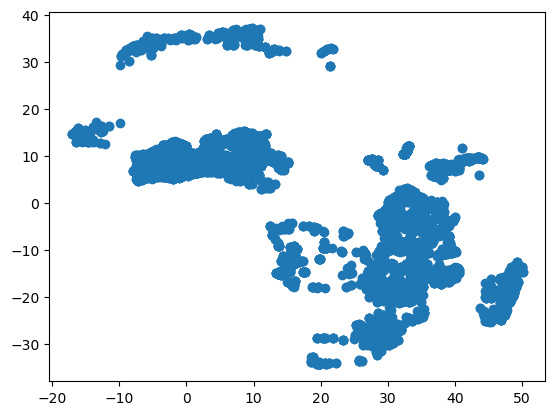

In [44]:
plt.scatter(data["longitude"], data["latitude"])
plt.show()